Finansal piyasalarda ajanların oyun teorisine dayalı stratejilerini Mesa framework’ü ile simüle etmek çok güçlü sonuçlar verebilir. Hadi adım adım gidelim.

🎯 Amaç:
Mesa’da bir piyasa ortamı kurup, ajanlara farklı oyun teorisi tabanlı stratejiler vererek nasıl davranacaklarını gözlemlemek.

Örneğin, basit bir senaryoda:

Bazı ajanlar “Taklitçi (herding)” stratejisi uygulasın.

Bazıları “Dominant strateji” izlesin.

Bazıları ise “Cezalandırıcı (tit-for-tat)” stratejiyle hareket etsin.

🧱 Yapı:
Model Sınıfı – MarketModel

Ajan Sınıfı – InvestorAgent

Strateji Türleri:

'herding' (taklit)

'dominant' (her durumda aynı hareket)

'tit_for_tat' (geçmişteki karşılıklı davranışa göre)

In [ ]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

import random

In [31]:

class InvestorAgent(mesa.Agent):
    def __init__(self,model, strategy):
        super().__init__( model)
        self.strategy = strategy
        self.last_move = None
        self.history = {}

    def step(self):
        import random
        if self.strategy == "dominant":
            self.dominant_strategy()
        elif self.strategy == "herding":
            self.herding_strategy()
        elif self.strategy == "tit_for_tat":
            self.tit_for_tat_strategy()
        else:
            self.last_move = "hold"

    def dominant_strategy(self):
        self.last_move = "buy"

    def herding_strategy(self):
        others = [agent for agent in self.model.agents if agent.unique_id != self.unique_id]
        recent_moves = [a.last_move for a in others if a.last_move is not None]
        if recent_moves:
            self.last_move = max(set(recent_moves), key=recent_moves.count)
        else:
            self.last_move = random.choice(["buy", "sell", "hold"])

    def tit_for_tat_strategy(self):
        opponent = self.model.find_opponent(self)
        if opponent and opponent.unique_id in self.history:
            self.last_move = self.history[opponent.unique_id]
        else:
            self.last_move = "buy"  # başta iyi niyetli başla
        if opponent:
            self.history[opponent.unique_id] = opponent.last_move


class MarketModel(mesa.Model):
    def __init__(self, N):
        super().__init__()

        self.num_agents = N

        strategies = ["dominant", "herding", "tit_for_tat"]
        for i in range(self.num_agents):
            strategy = random.choice(strategies)
            agent = InvestorAgent(self, strategy)
            self.agents.add(agent)

    def step(self):
        self.agents.do("step")

    def find_opponent(self, agent):
        others = [a for a in self.agents if a.unique_id != agent.unique_id]
        return random.choice(others) if others else None


In [34]:
model = MarketModel(10)
for i in range(20):
    model.step()
    print(f"Step {i}:")
    for a in model.agents:
        print(f"Agent {a.unique_id} ({a.strategy}): {a.last_move}")


Step 0:
Agent 1 (dominant): buy
Agent 2 (dominant): buy
Agent 3 (tit_for_tat): buy
Agent 4 (herding): buy
Agent 5 (tit_for_tat): buy
Agent 6 (tit_for_tat): buy
Agent 7 (tit_for_tat): buy
Agent 8 (dominant): buy
Agent 9 (tit_for_tat): buy
Agent 10 (herding): buy
Step 1:
Agent 1 (dominant): buy
Agent 2 (dominant): buy
Agent 3 (tit_for_tat): buy
Agent 4 (herding): buy
Agent 5 (tit_for_tat): buy
Agent 6 (tit_for_tat): buy
Agent 7 (tit_for_tat): buy
Agent 8 (dominant): buy
Agent 9 (tit_for_tat): buy
Agent 10 (herding): buy
Step 2:
Agent 1 (dominant): buy
Agent 2 (dominant): buy
Agent 3 (tit_for_tat): buy
Agent 4 (herding): buy
Agent 5 (tit_for_tat): buy
Agent 6 (tit_for_tat): buy
Agent 7 (tit_for_tat): buy
Agent 8 (dominant): buy
Agent 9 (tit_for_tat): buy
Agent 10 (herding): buy
Step 3:
Agent 1 (dominant): buy
Agent 2 (dominant): buy
Agent 3 (tit_for_tat): buy
Agent 4 (herding): buy
Agent 5 (tit_for_tat): None
Agent 6 (tit_for_tat): buy
Agent 7 (tit_for_tat): buy
Agent 8 (dominant): buy
Ag

ajanların stratejilerini zamanla değiştirip, bir evrimsel oyun modeli haline getirebilirsiniz.

Evrimsel oyun kuramı, ajanların zamanla başarılı stratejileri öğrenip taklit ettiği, başarısızlardan vazgeçtiği bir ortam yaratır. Mesa ile bunu yapmak oldukça keyifli ve güçlü sonuçlar doğurur.

🧬 Hedefimiz:
Ajanlar zaman içinde performanslarına göre:

Kendi stratejilerini değiştirsin,

Başarılı ajanları taklit etsin,

Böylece popüler ve etkili stratejiler evrimleşsin.

⚙️ YENİ ÖZELLİKLER
Ajanlara ekliyoruz:
score: Ajanın performansını temsil eder (örn. kar-zarar).

Her adımda score güncellenir.

Belirli aralıklarla (örn. her 5 adımda bir), başarısız ajanlar başarılı olanları taklit ederek strateji değiştirir.

yukarıdaki kod ne yapıyor

Kodu adım adım açıklayalım:

1. Ajanlar (InvestorAgent)

Başlatma (__init__): Her ajan bir strateji (dominant, herding, tit_for_tat) ile başlar. last_move son hareketini, history geçmiş etkileşimlerini ve score performans puanını tutar.
Adım (step): Her turda ajan stratejisine göre bir hareket yapar (buy, sell, hold) ve update_score ile puanını günceller.
Puan Güncelleme (update_score): Hareketine göre puanı rastgele artar ya da azalır.
Stratejiler (dominant_strategy, herding_strategy, tit_for_tat_strategy):
dominant_strategy: Her zaman "buy" yapar.
herding_strategy: Diğer ajanların çoğunluğunun yaptığı hareketi taklit eder.
tit_for_tat_strategy: Bir önceki turda rakibinin yaptığı hareketi tekrarlar.
Strateji Kopyalama (copy_strategy_from): Başarısız ajanlar, başarılı ajanların stratejisini kopyalar.
2. Model (MarketModel)

Başlatma (__init__): Belirli sayıda ajan oluşturur ve rastgele stratejiler atar.
Adım (step): Tüm ajanların step fonksiyonunu çağırır, tur sayısını artırır ve belirli aralıklarla evolve_strategies ile evrimsel güncelleme yapar.
Evrim (evolve_strategies): En iyi performans gösteren ajanların stratejilerini, en kötü performans gösteren ajanlara kopyalar. Bu, başarılı stratejilerin zamanla yayılmasını sağlar.
Rakip Bulma (find_opponent): tit_for_tat stratejisi için rastgele bir rakip ajan seçer.
3. Simülasyon

MarketModel(1000): 1000 ajanlı bir model oluşturur.
30 tur boyunca simülasyonu çalıştırır ve her turda ajanların durumlarını (strateji ve puan) yazdırır.
Özetle, kod bir piyasa simülasyonu yapıyor. Ajanlar farklı stratejilerle hareket ediyor ve performanslarına göre stratejilerini değiştiriyorlar. Evrimsel oyun teorisi prensiplerine göre, başarılı stratejiler zamanla yayılıyor ve piyasanın davranışını etkiliyor.

Amaç:

Bu kodun amacı, farklı yatırım stratejilerinin bir piyasada nasıl etkileşime girdiğini ve zaman içinde nasıl evrimleştiğini gözlemlemektir. Ajan tabanlı modelleme sayesinde, karmaşık piyasa dinamiklerini daha iyi anlamak ve potansiyel olarak daha etkili stratejiler geliştirmek mümkün olabilir.

yukarıdaki kod ne yapıyor

Kodu adım adım açıklayalım:

1. Ajanlar (InvestorAgent)

Başlatma (__init__): Her ajan bir strateji (dominant, herding, tit_for_tat) ile başlar. last_move son hareketini, history geçmiş etkileşimlerini ve score performans puanını tutar.
Adım (step): Her turda ajan stratejisine göre bir hareket yapar (buy, sell, hold) ve update_score ile puanını günceller.
Puan Güncelleme (update_score): Hareketine göre puanı rastgele artar ya da azalır.
Stratejiler (dominant_strategy, herding_strategy, tit_for_tat_strategy):
dominant_strategy: Her zaman "buy" yapar.
herding_strategy: Diğer ajanların çoğunluğunun yaptığı hareketi taklit eder.
tit_for_tat_strategy: Bir önceki turda rakibinin yaptığı hareketi tekrarlar.
Strateji Kopyalama (copy_strategy_from): Başarısız ajanlar, başarılı ajanların stratejisini kopyalar.
2. Model (MarketModel)

Başlatma (__init__): Belirli sayıda ajan oluşturur ve rastgele stratejiler atar.
Adım (step): Tüm ajanların step fonksiyonunu çağırır, tur sayısını artırır ve belirli aralıklarla evolve_strategies ile evrimsel güncelleme yapar.
Evrim (evolve_strategies): En iyi performans gösteren ajanların stratejilerini, en kötü performans gösteren ajanlara kopyalar. Bu, başarılı stratejilerin zamanla yayılmasını sağlar.
Rakip Bulma (find_opponent): tit_for_tat stratejisi için rastgele bir rakip ajan seçer.
3. Simülasyon

MarketModel(1000): 1000 ajanlı bir model oluşturur.
30 tur boyunca simülasyonu çalıştırır ve her turda ajanların durumlarını (strateji ve puan) yazdırır.
Özetle, kod bir piyasa simülasyonu yapıyor. Ajanlar farklı stratejilerle hareket ediyor ve performanslarına göre stratejilerini değiştiriyorlar. Evrimsel oyun teorisi prensiplerine göre, başarılı stratejiler zamanla yayılıyor ve piyasanın davranışını etkiliyor.

Amaç:

Bu kodun amacı, farklı yatırım stratejilerinin bir piyasada nasıl etkileşime girdiğini ve zaman içinde nasıl evrimleştiğini gözlemlemektir. Ajan tabanlı modelleme sayesinde, karmaşık piyasa dinamiklerini daha iyi anlamak ve potansiyel olarak daha etkili stratejiler geliştirmek mümkün olabilir.

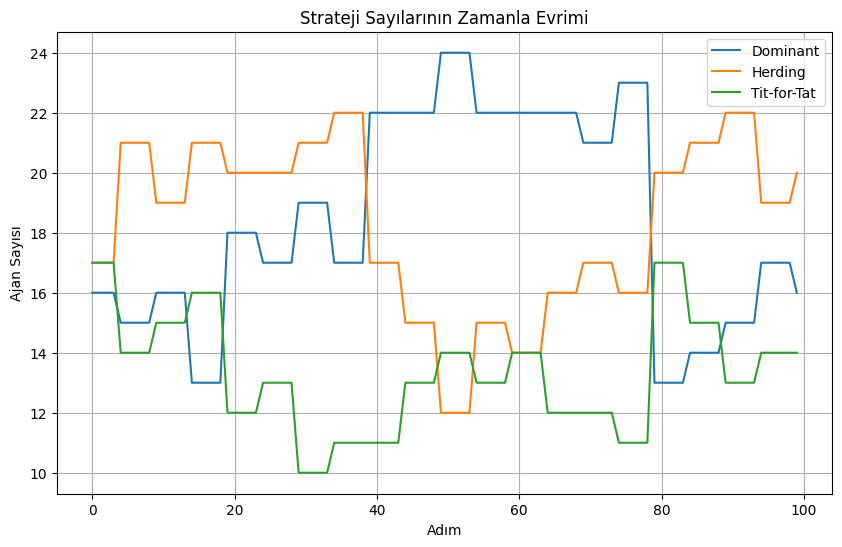

In [79]:
# Gerekli kütüphaneler

import random
import matplotlib.pyplot as plt
from mesa.datacollection import DataCollector

# === Ajan sınıfı ===


class InvestorAgent(mesa.Agent):
    def __init__(self,model, strategy):
        super().__init__( model)
        self.strategy = strategy
        self.last_move = None
        self.history = {}
        self.score = 0  # Yeni: performans puanı

    def step(self):
        # Stratejiye göre hareket
        if self.strategy == "dominant":
            self.dominant_strategy()
        elif self.strategy == "herding":
            self.herding_strategy()
        elif self.strategy == "tit_for_tat":
            self.tit_for_tat_strategy()
        else:
            self.last_move = "hold"

        # Her adımda rastgele bir getiri kazan ya da kaybet
        self.update_score()

    def update_score(self):
        """Basit: Buy -> +1, Sell -> -1, Hold -> 0"""
        if self.last_move == "buy":
            self.score += random.choice([1, -1])
        elif self.last_move == "sell":
            self.score += random.choice([1, -1])
        # hold = 0 etkisi

    def dominant_strategy(self):
        self.last_move = "buy"

    def herding_strategy(self):
        others = [agent for agent in self.model.agents if agent.unique_id != self.unique_id]
        recent_moves = [a.last_move for a in others if a.last_move is not None]
        if recent_moves:
            self.last_move = max(set(recent_moves), key=recent_moves.count)
        else:
            self.last_move = random.choice(["buy", "sell", "hold"])

    def tit_for_tat_strategy(self):
        opponent = self.model.find_opponent(self)
        if opponent and opponent.unique_id in self.history:
            self.last_move = self.history[opponent.unique_id]
        else:
            self.last_move = "buy"  # başta iyi niyetli başla
        if opponent:
            self.history[opponent.unique_id] = opponent.last_move

    def copy_strategy_from(self, other_agent):
        self.strategy = other_agent.strategy
        self.history = {}  # önceki stratejiye ait veri sıfırlanır


# === Strateji sayacı ===
def count_strategy(model, strategy_name):
    return sum(1 for a in model.agents if a.strategy == strategy_name)

# === Model sınıfı ===
class MarketModel(mesa.Model):
    def __init__(self, N=30):
        super().__init__()
        self.num_agents = N

        self.steps = 0

        strategies = ["dominant", "herding", "tit_for_tat"]
        for i in range(self.num_agents):
            strategy = random.choice(strategies)
            agent = InvestorAgent(self, strategy)
            self.agents.add(agent)

        self.datacollector = DataCollector(
            model_reporters={
                "Dominant": lambda m: count_strategy(m, "dominant"),
                "Herding": lambda m: count_strategy(m, "herding"),
                "Tit-for-Tat": lambda m: count_strategy(m, "tit_for_tat")
            }
        )

    def step(self):
        self.agents.do("step")
        self.steps += 1
        if self.steps % 5 == 0:
            self.evolve_strategies()
        self.datacollector.collect(self)

    def evolve_strategies(self):
        # Rastgele bir strateji değişimi — evrimsel dinamikleri temsil eder
        for agent in self.agents:
            if random.random() < 0.2:
                agent.strategy = random.choice(["dominant", "herding", "tit_for_tat"])

    def find_opponent(self, agent): # Added: find_opponent method to MarketModel
        others = [a for a in self.agents if a.unique_id != agent.unique_id] # Changed: self.agents to self.schedule.agents
        return random.choice(others) if others else None


# === Modeli çalıştır ===
model = MarketModel(N=50)
for _ in range(100):
    model.step()

# === Veri görselleştirme ===
data = model.datacollector.get_model_vars_dataframe()

plt.figure(figsize=(10, 6))
for col in data.columns:
    plt.plot(data[col], label=col)

plt.title("Strateji Sayılarının Zamanla Evrimi")
plt.xlabel("Adım")
plt.ylabel("Ajan Sayısı")
plt.legend()
plt.grid(True)
plt.show()


işte kodun özeti:

🎯 Amaç:
Yatırımcı ajanlar farklı stratejilerle (dominant, herding, tit-for-tat) işlem yapar. Zamanla bu stratejiler evrimsel olarak değişir ve dağılım görselleştirilir.

👤 Ajanlar (InvestorAgent):
Her ajanın bir stratejisi ve skoru vardır.

Stratejilere göre işlem yapar:

Dominant: Hep "buy"

Herding: Çoğunluğu taklit eder

Tit-for-Tat: Rakibin önceki hamlesini taklit eder

İşlemler sonucu skorları değişir.

🔁 Model (MarketModel):
Her 5 adımda bazı ajanlar rastgele strateji değiştirir (evrimsel değişim).

Adım adım ajanların strateji dağılımı toplanır.

📈 Çıktı:
100 adım çalıştırılır.

Zamanla her stratejiyi kullanan ajan sayısı çizilir.

